## Dit is een eerste poging van een model werkend krijgen
De eerste run zal de route van Ischa Hollemans gebruiken. 
De tweede run zal (hopelijk) de route van Maxime gebruiken. 
Daarna zelf een manier vinden om dingen netjes neer te zetten, gebruiken en valideren. 
Rivier in Frans-Guyana heet de "Approugue"

In [1]:
# importeren om te kunnen werken
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [2]:
# stroomgebied naam
basin_name = "Frans"

# tijdsinterval
start_datum = "2017-01-01"
eind_datum = "2021-12-31"

# route naar shape file
shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.shp"

# route naar forcing ERA5 data
forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_2017_2021"/ "work" / "diagnostic" / "script"
forcing_route.mkdir(exist_ok=True)

# route naar hbv 
HBV_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "hbv_bmi"
HBV_model.mkdir(exist_ok=True)

# route naar discharge file, van Maxime
discharge_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.csv"

# stroomgebied oppervlakte im km^2
frans_area = 7.638586e+03 

                           Date    Value
9144  2017-01-01 00:00:00+00:00  138.547
9145  2017-01-02 00:00:00+00:00  132.485
9146  2017-01-03 00:00:00+00:00  162.360
9147  2017-01-04 00:00:00+00:00  179.180
9148  2017-01-05 00:00:00+00:00  196.999
...                         ...      ...
10965 2021-12-27 00:00:00+00:00  875.271
10966 2021-12-28 00:00:00+00:00  799.095
10967 2021-12-29 00:00:00+00:00  713.189
10968 2021-12-30 00:00:00+00:00  626.093
10969 2021-12-31 00:00:00+00:00  554.588

[1826 rows x 2 columns]


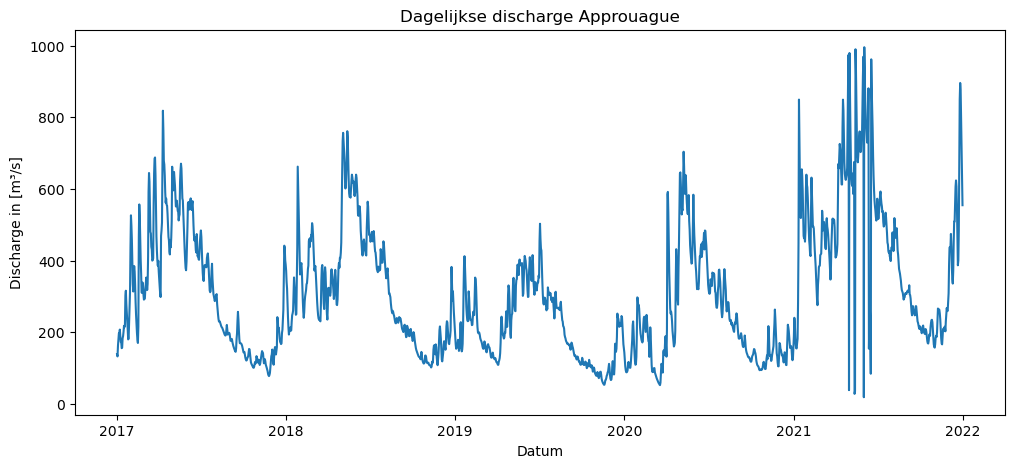

In [3]:
df = pd.read_csv(discharge_file, delimiter=';')
df["Value"] = df["Value"]/1000 # excel formatting van engels naar nederlands. Kan in excel worden opgelost maar ik ben lui
# df = pd.read_csv(discharge_file, delimiter=';', header = 0,  index_col=[0], parse_dates = True)
df.replace(999000, np.nan, inplace=True)
# print(df)

df["Date"] = pd.to_datetime(df["Date"], utc = True)
# print(df)
# print("Max = ",df["Value"].max())

# start_date = pd.to_datetime(start_datum.replace("Z", ""))
# end_date = pd.to_datetime(eind_datum.replace("Z", ""))

start_date = pd.to_datetime(start_datum, utc=True)
end_date = pd.to_datetime(eind_datum, utc=True)

df = df[
    (df["Date"] >= start_date) &
    (df["Date"] <= end_date)
].copy()

start_time_utc = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
end_time_utc = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")

df.head()
print(df)

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Value"])
plt.xlabel("Datum")
plt.ylabel("Discharge in [m³/s]")
plt.title("Dagelijkse discharge Approuague")
plt.show()

In [4]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=start_time_utc,
#     end_time=end_time_utc,
#     shape=shapefile,
#     directory=forcing_route
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)
# ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
#     directory=ERA5_forcing.directory)

print(f"The forcing object you created: \n {ERA5_forcing}")

The forcing object you created: 
 start_time='2017-01-01T00:00:00Z' end_time='2021-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script/Frans.shp') filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_2017-2021.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_2017-2021.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2017-2021.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


<xarray.DataArray 'evspsblpot' (time: 1826)> Size: 7kB
dask.array<open_dataset-evspsblpot, shape=(1826,), dtype=float32, chunksize=(1826,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 15kB 2017-01-01T12:00:00 ... 2021-12-31T12...
    lat      float64 8B 3.75
    lon      float64 8B -52.75
Attributes:
    standard_name:  water_potential_evaporation_flux
    units:          kg m-2 s-1
    long_name:      potential evaporation
<xarray.DataArray 'pr' (time: 1826)> Size: 7kB
dask.array<open_dataset-pr, shape=(1826,), dtype=float32, chunksize=(1826,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 15kB 2017-01-01T12:00:00 ... 2021-12-31T12...
    lat      float64 8B 3.75
    lon      float64 8B -52.75
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    cell_methods:   day_of_year: year: mean latitude: longitude: mean


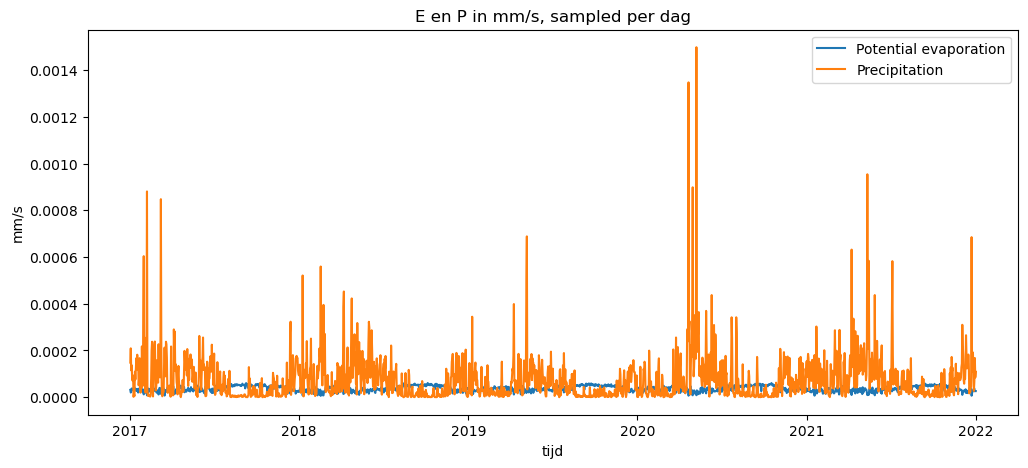

In [5]:
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
print(evap)
print(prec)
fig, ax = plt.subplots(figsize=(12,5))

evap.plot(ax=ax, label='Potential evaporation')
prec.plot(ax=ax, label='Precipitation')
ax.set_ylabel('mm/s')
ax.set_xlabel("tijd")
plt.title("E en P in mm/s, sampled per dag")
ax.legend();

5.910094e-06 6.0760667e-05
-1.9274704e-18 0.0014977145


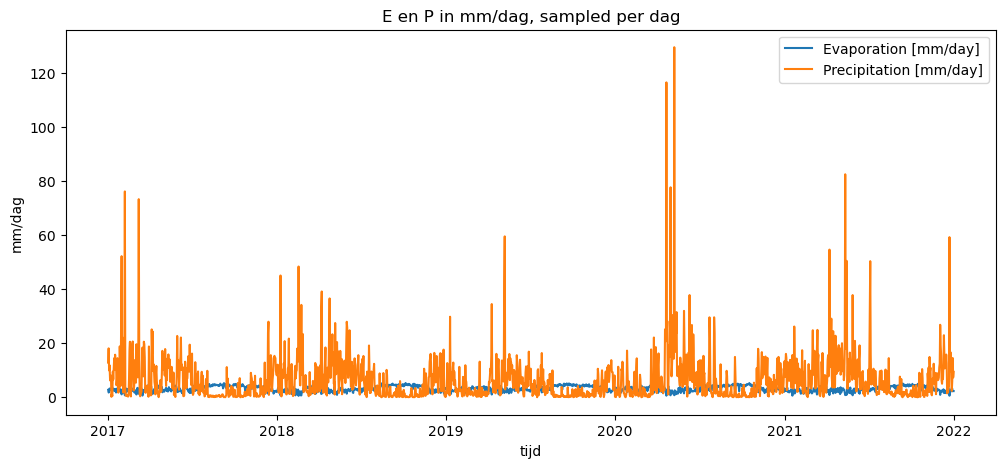

In [6]:
print(evap.min().values, evap.max().values)
print(prec.min().values, prec.max().values)
evap_dag = evap*3600*24
prec_dag = prec*3600*24
fig, ax = plt.subplots(figsize=(12,5))
evap_dag.plot(ax=ax, label="Evaporation [mm/day]")
prec_dag.plot(ax=ax, label="Precipitation [mm/day]")

ax.set_ylabel("mm/dag")
ax.set_xlabel("tijd")
ax.legend()
plt.title("E en P in mm/dag, sampled per dag")
plt.show()

In [19]:
#gekopieerd van Maxime
(2.556,), (0.447,), (695.187,), (0.684,), (0.244,), (6.36,), (0.033,), (0.005,), (0.761,)
# par_0 = [2.79874, 0.49211, 255.96478, 1.782968, 0.503199, 6.095956, 0.33279, 0.10539, 0.63857] #test 

# par_0 = [2.55637418e+00, 4.47358046e-01, 6.95187203e+02, 6.83521135e-01, 2.43678245e-01, 6.36004189e+00, 3.33407748e-02, 4.95282781e-03, 7.61410830e-01] #1
par_0 = [6.91317584e+00, 3.70823669e-01, 9.69776327e+01, 9.55615846e-01, 1.30160289e-01, 1.22201050e+00, 1.65561198e-02, 4.65817605e-03, 4.01407442e-07] #2

par_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]   

# Maximum interception storage
# Evaporation correction factor
# Maximum soil moisture storage
# Soil runoff parameter
# Maximum percolation rate
# Time lag
# Fast reservoir recession coefficient
# Slow reservoir recession coefficient
# Snowmelt factor

print(list(zip(par_names, par_0)))
#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

[('Imax', 6.91317584), ('Ce', 0.370823669), ('Sumax', 96.9776327), ('Beta', 0.955615846), ('Pmax', 0.130160289), ('Tlag', 1.2220105), ('Kf', 0.0165561198), ('Ks', 0.00465817605), ('FM', 4.01407442e-07)]


In [20]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

In [21]:
config_file, _ = model.setup(parameters=par_0, initial_storages=s_0, cfg_dir=HBV_model)

In [22]:
model.initialize(config_file)

In [23]:
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [24]:
model.finalize()

In [25]:
# Make Series for model output and q_obs
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
print(model_output_mmday.max())
model_output_m3s = model_output_mmday * frans_area * 1000 / 86400
print(model_output_m3s.max())
model_output_m3s = model_output_m3s.mask(model_output_m3s > 1300, np.nan)
print(model_output_m3s.max())

# Date_obs = q_obs["Date"]
# discharge_m3s_obs = q_obs["discharge_m3s"]

observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])

# q_obs.set_index("Date")["discharge_m3s"]
# observed_output.name = "Observed discharge"

9.491577056379594
839.1461530183145
839.1461530183145


grdc =                             Date    Value
9144  2017-01-01 00:00:00+00:00  138.547
9145  2017-01-02 00:00:00+00:00  132.485
9146  2017-01-03 00:00:00+00:00  162.360
9147  2017-01-04 00:00:00+00:00  179.180
9148  2017-01-05 00:00:00+00:00  196.999
...                         ...      ...
10965 2021-12-27 00:00:00+00:00  875.271
10966 2021-12-28 00:00:00+00:00  799.095
10967 2021-12-29 00:00:00+00:00  713.189
10968 2021-12-30 00:00:00+00:00  626.093
10969 2021-12-31 00:00:00+00:00  554.588

[1826 rows x 2 columns]
model = 2017-01-02 12:00:00      0.003004
2017-01-03 12:00:00      1.697348
2017-01-04 12:00:00      5.087027
2017-01-05 12:00:00     10.154035
2017-01-06 12:00:00     13.544933
                          ...    
2021-12-27 12:00:00    354.146086
2021-12-28 12:00:00    350.786766
2021-12-29 12:00:00    350.722925
2021-12-30 12:00:00    358.090144
2021-12-31 12:00:00    359.004827
Name: Modelled discharge, Length: 1825, dtype: float64


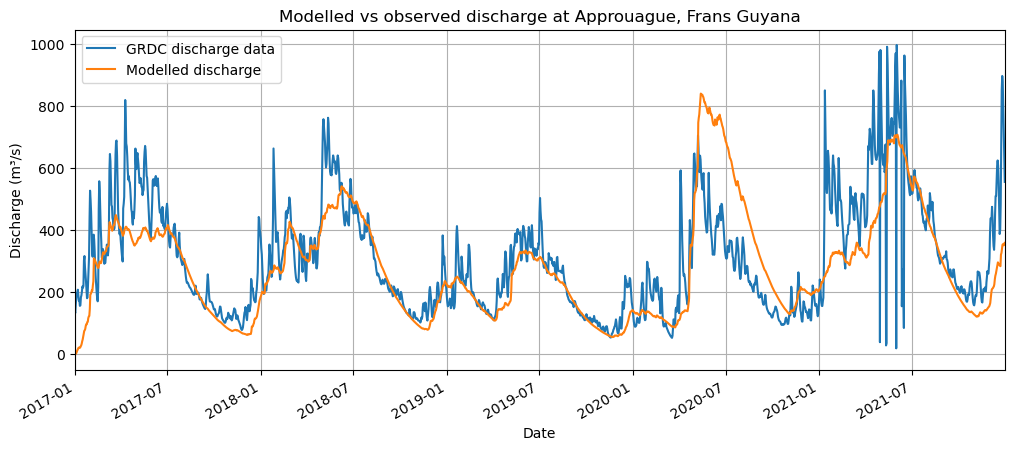

In [26]:
plt.figure(figsize=(12, 5))

q_critical = 500

plt.plot(df["Date"], df["Value"], label = "GRDC discharge data")
model_output_m3s.plot(label="Modelled discharge")
print("grdc = ",df)
print("model =", model_output_m3s)

# df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
# df["Date"] = df["Date"].dt.normalize()   
# model_output_m3s.index = pd.to_datetime(model_output_m3s.index)
# model_output_m3s.index = model_output_m3s.index.normalize()

# print("grdc = ",df)
# print("model =", model_output_m3s)

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Modelled vs observed discharge at Approuague, Frans Guyana")
plt.legend()
plt.grid(True)
plt.xlim("2017-01-01", "2021-12-31")

plt.show()